# 🔹 Objective 1 — Part 2: Baseline Comparison + Model Saving

## Baselines Implemented

| # | Baseline Model | What It Does | Why It's a Fair Baseline |
|---|---|---|---|
| 1 | **TF-IDF + Cosine** | Sparse bag-of-words vector similarity on `spec_text_raw` vs `product_name` | Classic IR baseline; no training needed |
| 2 | **BM25** | Probabilistic term-weighting retrieval (Okapi BM25) | Gold standard for lexical retrieval in IR |
| 3 | **SBERT (MiniLM-L6)** | Lightweight dense semantic model (all-MiniLM-L6-v2) | Faster, smaller SBERT — tests if bigger model helps |
| 4 | **SBERT (MPNet)** | Your current semantic component (all-mpnet-base-v2) | Semantic-only upper bound for dense retrieval |
| 5 | **Exact Field Match** | Hard exact match on all structured attributes | Strict rule-based baseline |
| 6 | **Random Baseline** | Random SKU ranking | Lower bound — any real model should beat this |
| 7 | **🏆 Your Hybrid Model** | Struct(0.5) + Semantic(0.3) + Standards(0.2) with mandatory-spec weighting | Your Objective 1 contribution |

## Model Saving Strategy
Everything needed for Objective 2 is saved to `obj1_model_artifacts/`:
- `match_df.parquet` — full 7000×200 scored pair matrix
- `rfp_df_with_gt.parquet` — RFP dataframe with ground truth labels
- `product_df.parquet` — product catalog
- `rfp_embeddings.npy` — pre-computed MPNet RFP embeddings
- `product_embeddings.npy` — pre-computed MPNet product embeddings
- `model_config.json` — best weights, K, column names, model name
- `baseline_results.csv` — all baseline metrics for comparison in Obj 2

In [ ]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================
# Run this cell once on a fresh Colab session
!pip install -q sentence-transformers scikit-learn rank-bm25 pandas numpy matplotlib tabulate

In [ ]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from typing import Dict, List, Optional, Tuple
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

warnings.filterwarnings('ignore')
np.random.seed(42)

ARTIFACT_DIR = 'obj1_model_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print('✅ Imports done.')
print(f'📁 Artifacts will be saved to: {ARTIFACT_DIR}/')

✅ Imports done.
📁 Artifacts will be saved to: obj1_model_artifacts/


In [ ]:
# ============================================================
# CELL 3 — LOAD DATASETS
# Upload product_catalog.csv and rfp_specs_7000.csv to Colab
# ============================================================
product_df = pd.read_csv('product_catalog.csv')
rfp_df     = pd.read_csv('rfp_specs_7000.csv')

product_df.columns = product_df.columns.str.strip()
rfp_df.columns     = rfp_df.columns.str.strip()

product_df = product_df.reset_index(drop=True)
rfp_df     = rfp_df.reset_index(drop=True)

N_RFP = len(rfp_df)
N_SKU = len(product_df)

print(f'Product catalog : {product_df.shape}')
print(f'RFP specs       : {rfp_df.shape}')
print(f'Total pairs     : {N_RFP * N_SKU:,}')

Product catalog : (200, 16)
RFP specs       : (7000, 17)
Total pairs     : 1,400,000


In [ ]:
# ============================================================
# CELL 4 — SHARED SCORING FUNCTIONS FROM FIXED OBJECTIVE 1
# (copied here so this notebook is fully self-contained)
# ============================================================

_SIZE_LADDER = [
    0.5, 0.75, 1.0, 1.5, 2.5, 4.0, 6.0, 10.0, 16.0,
    25.0, 35.0, 50.0, 70.0, 95.0, 120.0, 150.0, 185.0,
    240.0, 300.0, 400.0, 500.0, 630.0, 800.0, 1000.0
]
_SIZE_SET = set(_SIZE_LADDER)

def _adjacent_sizes(val: float) -> set:
    if val not in _SIZE_SET:
        val = min(_SIZE_LADDER, key=lambda x: abs(x - val))
    idx = _SIZE_LADDER.index(val)
    neighbours = {val}
    if idx > 0:              neighbours.add(_SIZE_LADDER[idx - 1])
    if idx < len(_SIZE_LADDER) - 1: neighbours.add(_SIZE_LADDER[idx + 1])
    return neighbours


def structured_score(rfp_row: pd.Series, sku_row: pd.Series) -> float:
    mandatory_raw = str(rfp_row.get('mandatory_specs', ''))
    mandatory = set(f.strip() for f in mandatory_raw.split(';') if f.strip())

    exact_fields = [
        'voltage_rating', 'conductor_material', 'insulation_type',
        'sheath_type', 'temperature_rating', 'fire_resistance', 'armouring'
    ]
    score = 0.0; total = 0.0

    for field in exact_fields:
        w = 2.0 if field in mandatory else 1.0
        total += w
        if str(rfp_row.get(field,'')).strip().lower() == str(sku_row.get(field,'')).strip().lower():
            score += w

    w_cc = 2.0 if 'core_count' in mandatory else 1.0
    total += w_cc
    try:
        if int(float(rfp_row['core_count'])) == int(float(sku_row['core_count'])):
            score += w_cc
    except: pass

    w_sz = 2.0 if 'size_sqmm' in mandatory else 1.0
    total += w_sz
    try:
        if float(sku_row['size_sqmm']) in _adjacent_sizes(float(rfp_row['size_sqmm'])):
            score += w_sz
    except: pass

    return score / total if total > 0 else 0.0


def standards_score(rfp_row: pd.Series, sku_row: pd.Series) -> float:
    rfp_std = str(rfp_row.get('standards_required', '')).strip().lower()
    sku_std = str(sku_row.get('standards_complied', '')).strip().lower()
    if not rfp_std or rfp_std == 'nan': return 0.0
    return 1.0 if (rfp_std in sku_std or sku_std in rfp_std) else 0.0


def _token_jaccard(a: str, b: str) -> float:
    sa = set(str(a).lower().split())
    sb = set(str(b).lower().split())
    if not sa and not sb: return 0.0
    return len(sa & sb) / len(sa | sb)


print('✅ Shared scoring functions defined.')

✅ Shared scoring functions defined.


In [ ]:
# ============================================================
# CELL 5 — ENCODE WITH BOTH SBERT MODELS
# ============================================================
product_texts = product_df['product_name'].astype(str).tolist()
rfp_texts     = rfp_df['spec_text_raw'].astype(str).tolist()

# ── MPNet (your main model) ─────────────────────────────────
print('Loading all-mpnet-base-v2...')
t0 = time.time()
mpnet_model = SentenceTransformer('all-mpnet-base-v2')
product_emb_mpnet = mpnet_model.encode(product_texts, batch_size=64,
                                        normalize_embeddings=True,
                                        show_progress_bar=True)
rfp_emb_mpnet     = mpnet_model.encode(rfp_texts, batch_size=64,
                                        normalize_embeddings=True,
                                        show_progress_bar=True)
sem_matrix_mpnet  = (rfp_emb_mpnet @ product_emb_mpnet.T).astype(np.float32)
print(f'MPNet done in {time.time()-t0:.1f}s  |  matrix: {sem_matrix_mpnet.shape}')

# ── MiniLM-L6 (lightweight baseline) ───────────────────────
print('\nLoading all-MiniLM-L6-v2...')
t1 = time.time()
minilm_model      = SentenceTransformer('all-MiniLM-L6-v2')
product_emb_mini  = minilm_model.encode(product_texts, batch_size=128,
                                         normalize_embeddings=True,
                                         show_progress_bar=True)
rfp_emb_mini      = minilm_model.encode(rfp_texts, batch_size=128,
                                         normalize_embeddings=True,
                                         show_progress_bar=True)
sem_matrix_mini   = (rfp_emb_mini @ product_emb_mini.T).astype(np.float32)
print(f'MiniLM done in {time.time()-t1:.1f}s  |  matrix: {sem_matrix_mini.shape}')

Loading all-mpnet-base-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

MiniLM done in 108.9s  |  matrix: (7000, 200)


In [ ]:
# ============================================================
# CELL 6 — TF-IDF SIMILARITY MATRIX
# Baseline 1: sparse bag-of-words cosine similarity
# ============================================================
print('Computing TF-IDF matrix...')
t0 = time.time()

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=1,
    sublinear_tf=True      # log-normalised TF
)

# Fit on combined corpus so vocabulary is shared
all_texts = rfp_texts + product_texts
tfidf.fit(all_texts)

rfp_tfidf     = tfidf.transform(rfp_texts)
product_tfidf = tfidf.transform(product_texts)

# Cosine similarity: (N_RFP x V) · (V x N_SKU) — sparse matmul
tfidf_matrix  = (rfp_tfidf @ product_tfidf.T).toarray().astype(np.float32)

print(f'TF-IDF done in {time.time()-t0:.2f}s  |  matrix: {tfidf_matrix.shape}')

Computing TF-IDF matrix...
TF-IDF done in 0.40s  |  matrix: (7000, 200)


In [ ]:
# ============================================================
# CELL 7 — BM25 SCORE MATRIX
# Baseline 2: Okapi BM25 — gold standard lexical retrieval
# BM25 scores each RFP query against every product document
# ============================================================
print('Computing BM25 matrix...')
t0 = time.time()

# BM25 is query → corpus; corpus = product catalog
tokenised_corpus  = [doc.lower().split() for doc in product_texts]
bm25              = BM25Okapi(tokenised_corpus)

bm25_matrix = np.zeros((N_RFP, N_SKU), dtype=np.float32)
for i, rfp_text in enumerate(rfp_texts):
    query_tokens      = rfp_text.lower().split()
    scores            = bm25.get_scores(query_tokens)   # shape: (N_SKU,)
    bm25_matrix[i]    = scores.astype(np.float32)

# Normalise BM25 scores to [0, 1] per RFP so they're
# comparable to cosine similarity scores in metric reporting
row_max = bm25_matrix.max(axis=1, keepdims=True)
row_max[row_max == 0] = 1.0   # avoid divide-by-zero for all-zero rows
bm25_matrix_norm = bm25_matrix / row_max

print(f'BM25 done in {time.time()-t0:.1f}s  |  matrix: {bm25_matrix_norm.shape}')

Computing BM25 matrix...
BM25 done in 4.3s  |  matrix: (7000, 200)


In [ ]:
# ============================================================
# CELL 8 — BUILD FULL MATCH MATRIX WITH ALL SCORE COMPONENTS
# This runs once; all baselines reuse the same pair scores
# ============================================================
print('Building full match matrix (structured + standards for all pairs)...')
t0 = time.time()

struct_scores_mat  = np.zeros((N_RFP, N_SKU), dtype=np.float32)
std_scores_mat     = np.zeros((N_RFP, N_SKU), dtype=np.float32)

for i, rfp_row in rfp_df.iterrows():
    for j, sku_row in product_df.iterrows():
        struct_scores_mat[i, j] = structured_score(rfp_row, sku_row)
        std_scores_mat[i, j]    = standards_score(rfp_row, sku_row)

print(f'Done in {time.time()-t0:.1f}s')

# Build master match_df with ALL score types
rows = []
sku_ids_arr = product_df['sku_id'].values
rfp_ids_arr = rfp_df['rfp_id'].values

for i in range(N_RFP):
    for j in range(N_SKU):
        hybrid_score = (
            0.5 * struct_scores_mat[i, j]
          + 0.3 * sem_matrix_mpnet[i, j]
          + 0.2 * std_scores_mat[i, j]
        )
        rows.append((
            rfp_ids_arr[i], sku_ids_arr[j],
            struct_scores_mat[i, j],
            float(sem_matrix_mpnet[i, j]),
            float(sem_matrix_mini[i, j]),
            float(tfidf_matrix[i, j]),
            float(bm25_matrix_norm[i, j]),
            std_scores_mat[i, j],
            hybrid_score
        ))

match_df = pd.DataFrame(rows, columns=[
    'RFP_ID', 'SKU_ID',
    'Structured_Score',
    'Semantic_MPNet',
    'Semantic_MiniLM',
    'TF_IDF_Score',
    'BM25_Score',
    'Standards_Score',
    'Hybrid_Score'
])

print(f'match_df shape: {match_df.shape}')

Building full match matrix (structured + standards for all pairs)...
Done in 166.0s
match_df shape: (1400000, 9)


In [ ]:
# ============================================================
# CELL 9 — GROUND TRUTH (independent composite, no circularity)
# ============================================================
rfp_name_lookup  = rfp_df.set_index('rfp_id')['item_name'].to_dict() \
    if 'item_name' in rfp_df.columns else {}
prod_name_lookup = product_df.set_index('sku_id')['product_name'].to_dict()

gt_scores = [
    0.5 * row['Standards_Score']
    + 0.3 * row['Semantic_MPNet']
    + 0.2 * _token_jaccard(
        rfp_name_lookup.get(row['RFP_ID'], ''),
        prod_name_lookup.get(row['SKU_ID'], '')
    )
    for _, row in match_df.iterrows()
]
match_df['GT_Signal'] = gt_scores

gt_mapping = (
    match_df
    .loc[match_df.groupby('RFP_ID')['GT_Signal'].idxmax()]
    [['RFP_ID', 'SKU_ID']]
    .rename(columns={'RFP_ID': 'rfp_id', 'SKU_ID': 'ground_truth_sku'})
)

if 'ground_truth_sku' in rfp_df.columns:
    rfp_df = rfp_df.drop(columns=['ground_truth_sku'])
rfp_df = rfp_df.merge(gt_mapping, on='rfp_id', how='left')

gt_lookup = (
    rfp_df
    .dropna(subset=['ground_truth_sku'])
    .drop_duplicates('rfp_id')
    .set_index('rfp_id')['ground_truth_sku']
    .to_dict()
)

print(f'✅ Ground truth assigned for {len(gt_lookup)} RFPs')

✅ Ground truth assigned for 7000 RFPs


In [ ]:
# ============================================================
# CELL 10 — METRIC COMPUTATION ENGINE
# ============================================================

def build_match_groups(match_df: pd.DataFrame) -> Dict:
    groups = {}
    for rfp_id, grp in match_df.groupby('RFP_ID', sort=False):
        groups[rfp_id] = {
            'sku_id':     grp['SKU_ID'].to_numpy(),
            'structured': grp['Structured_Score'].to_numpy(dtype=np.float32),
            'mpnet':      grp['Semantic_MPNet'].to_numpy(dtype=np.float32),
            'minilm':     grp['Semantic_MiniLM'].to_numpy(dtype=np.float32),
            'tfidf':      grp['TF_IDF_Score'].to_numpy(dtype=np.float32),
            'bm25':       grp['BM25_Score'].to_numpy(dtype=np.float32),
            'standards':  grp['Standards_Score'].to_numpy(dtype=np.float32),
            'hybrid':     grp['Hybrid_Score'].to_numpy(dtype=np.float32),
        }
    return groups


def calculate_metrics(
    match_groups: Dict,
    ground_truth_by_rfp: Dict,
    score_key: str = 'hybrid',
    weights: Optional[Tuple] = None,
    K: int = 5
) -> Dict:
    top1 = 0; topk = 0; mrr_sum = 0.0
    prec_sum = 0.0; ndcg_sum = 0.0
    evaluated = 0

    for rfp_id, group in match_groups.items():
        gt = ground_truth_by_rfp.get(rfp_id)
        if gt is None: continue

        sku_ids = group['sku_id']

        if weights is not None:
            ws, we, wt = weights
            scores = (ws * group['structured']
                    + we * group['mpnet']
                    + wt * group['standards'])
        else:
            scores = group[score_key]

        order  = np.lexsort((sku_ids, -scores))
        ranked = sku_ids[order]

        positions = np.where(ranked == gt)[0]
        if len(positions) == 0: continue

        rank_pos = int(positions[0]) + 1
        evaluated += 1

        if rank_pos == 1: top1 += 1
        if rank_pos <= K:
            topk     += 1
            prec_sum += 1.0 / K
            ndcg_sum += 1.0 / np.log2(rank_pos + 1)
        mrr_sum += 1.0 / rank_pos

    if evaluated == 0:
        return {m: 0.0 for m in
                ['Top-1 Acc','Top-5 Acc','Recall@5','MRR','Precision@5','NDCG@5']}

    ideal_ndcg = 1.0 / np.log2(2)
    return {
        'Top-1 Acc':    top1     / evaluated,
        'Top-5 Acc':    topk     / evaluated,
        'Recall@5':     topk     / evaluated,
        'MRR':          mrr_sum  / evaluated,
        'Precision@5':  prec_sum / evaluated,
        'NDCG@5':      (ndcg_sum / evaluated) / ideal_ndcg,
    }


match_groups = build_match_groups(match_df)
print('✅ Metric engine ready.')

✅ Metric engine ready.


In [ ]:
# ============================================================
# CELL 11 — EVALUATE ALL MODELS
# ============================================================
K_VALUE = 5

# ── Baseline 6: Random ────────────────────────────────────
# Shuffle SKU ordering per RFP with a fixed seed
rng = np.random.default_rng(42)
random_groups = {}
for rfp_id, group in match_groups.items():
    rand_scores = rng.random(len(group['sku_id'])).astype(np.float32)
    random_groups[rfp_id] = {**group, 'random': rand_scores}

all_models = [
    # (label,                       score_key or weights)
    ('1. Random Baseline',          'random',      None),
    ('2. TF-IDF + Cosine',          'tfidf',       None),
    ('3. BM25 (Okapi)',             'bm25',        None),
    ('4. SBERT MiniLM-L6',          'minilm',      None),
    ('5. SBERT MPNet (sem-only)',    'mpnet',       None),
    ('6. Exact Structured Match',   'structured',  None),
    ('7. 🏆 Hybrid (Ours)',         'hybrid',      None),
]

results_rows = []
for label, score_key, weights in all_models:
    grp = random_groups if score_key == 'random' else match_groups
    m = calculate_metrics(grp, gt_lookup, score_key=score_key,
                          weights=weights, K=K_VALUE)
    results_rows.append({'Model': label, **m})
    print(f'{label:40s}  Top-1={m["Top-1 Acc"]:.4f}  MRR={m["MRR"]:.4f}  NDCG@5={m["NDCG@5"]:.4f}')

comparison_df = pd.DataFrame(results_rows)

print(f'\n{"="*90}')
print('  Full Baseline Comparison  (K=5)')
print(f'{"="*90}')
print(comparison_df.to_markdown(index=False, floatfmt='.4f'))

1. Random Baseline                        Top-1=0.0046  MRR=0.0298  NDCG@5=0.0160
2. TF-IDF + Cosine                        Top-1=0.1154  MRR=0.2312  NDCG@5=0.2208
3. BM25 (Okapi)                           Top-1=0.0559  MRR=0.1650  NDCG@5=0.1483
4. SBERT MiniLM-L6                        Top-1=0.1326  MRR=0.2316  NDCG@5=0.2318
5. SBERT MPNet (sem-only)                 Top-1=0.1653  MRR=0.2610  NDCG@5=0.2484
6. Exact Structured Match                 Top-1=0.0571  MRR=0.1295  NDCG@5=0.1168
7. 🏆 Hybrid (Ours)                        Top-1=0.1781  MRR=0.3088  NDCG@5=0.3124

  Full Baseline Comparison  (K=5)
| Model                     |   Top-1 Acc |   Top-5 Acc |   Recall@5 |    MRR |   Precision@5 |   NDCG@5 |
|:--------------------------|------------:|------------:|-----------:|-------:|--------------:|---------:|
| 1. Random Baseline        |      0.0046 |      0.0284 |     0.0284 | 0.0298 |        0.0057 |   0.0160 |
| 2. TF-IDF + Cosine        |      0.1154 |      0.3229 |     0.3229 |

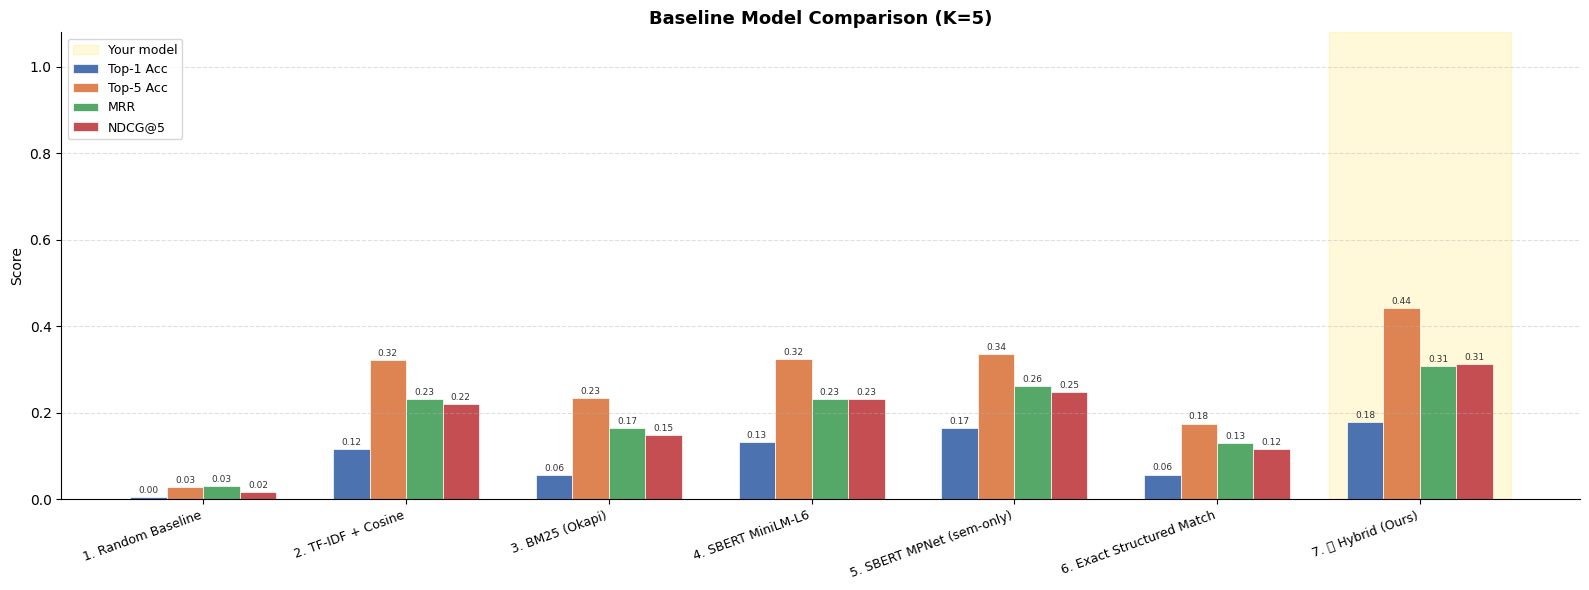

✅ Plot saved as baseline_comparison.png


In [ ]:
# ============================================================
# CELL 12 — VISUALISATION: GROUPED BAR CHART
# ============================================================
metrics_to_plot = ['Top-1 Acc', 'Top-5 Acc', 'MRR', 'NDCG@5']
models          = comparison_df['Model'].tolist()
x               = np.arange(len(models))
n_metrics       = len(metrics_to_plot)
bar_width       = 0.18
colors          = ['#4C72B0','#DD8452','#55A868','#C44E52']

fig, ax = plt.subplots(figsize=(16, 6))

for k, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    vals   = comparison_df[metric].values
    offset = (k - n_metrics / 2 + 0.5) * bar_width
    bars   = ax.bar(x + offset, vals, bar_width,
                    label=metric, color=color, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=6.5, color='#333333')

# Highlight the Hybrid bar group
hybrid_idx = [i for i, m in enumerate(models) if 'Hybrid' in m][0]
ax.axvspan(hybrid_idx - 0.45, hybrid_idx + 0.45,
           color='gold', alpha=0.15, zorder=0, label='Your model')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.set_title('Baseline Model Comparison (K=5)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as baseline_comparison.png')

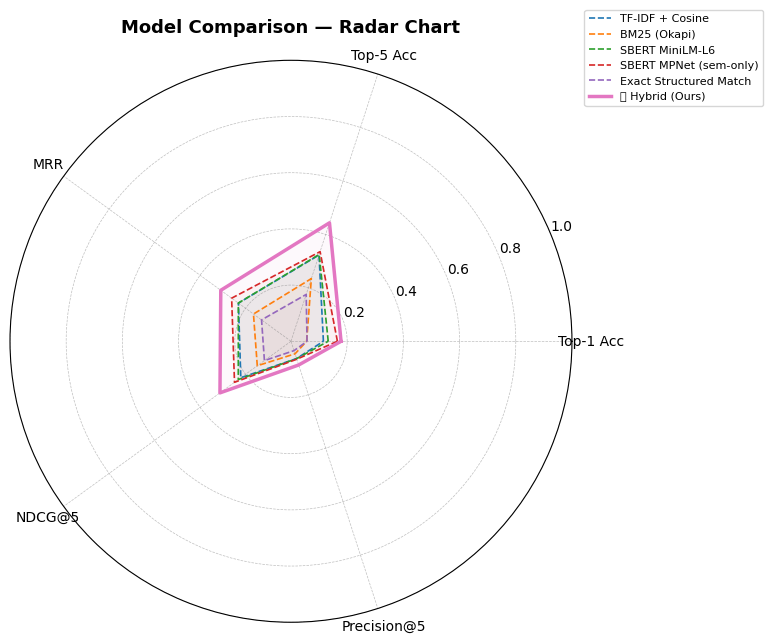

✅ Radar chart saved as radar_comparison.png


In [ ]:
# ============================================================
# CELL 13 — RADAR / SPIDER CHART
# ============================================================
from matplotlib.patches import FancyArrowPatch

radar_models  = ['TF-IDF + Cosine', 'BM25 (Okapi)',
                 'SBERT MiniLM-L6', 'SBERT MPNet (sem-only)',
                 'Exact Structured Match', '🏆 Hybrid (Ours)']
radar_metrics = ['Top-1 Acc', 'Top-5 Acc', 'MRR', 'NDCG@5', 'Precision@5']

# Filter comparison_df to only models that should appear in radar
radar_df = comparison_df[comparison_df['Model'].str.contains(
    '|'.join(['TF-IDF','BM25','MiniLM','MPNet','Structured','Hybrid'])
)].copy()

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(8, 8),
                        subplot_kw=dict(polar=True))

palette = plt.cm.tab10(np.linspace(0, 0.6, len(radar_df)))

for (_, row), color in zip(radar_df.iterrows(), palette):
    values = [float(row[m]) for m in radar_metrics]
    values += values[:1]
    lw = 2.5 if 'Hybrid' in row['Model'] else 1.2
    ls = '-'  if 'Hybrid' in row['Model'] else '--'
    ax.plot(angles, values, lw=lw, linestyle=ls, color=color,
            label=row['Model'].split('. ')[-1])
    ax.fill(angles, values, alpha=0.04, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, size=10)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison — Radar Chart', size=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Radar chart saved as radar_comparison.png')

In [ ]:
# ============================================================
# CELL 14 — IMPROVEMENT OVER BEST BASELINE
# ============================================================
non_hybrid = comparison_df[~comparison_df['Model'].str.contains('Hybrid')]
hybrid_row = comparison_df[comparison_df['Model'].str.contains('Hybrid')].iloc[0]

print('\n📊 Hybrid model improvement over best non-hybrid baseline:\n')
for metric in ['Top-1 Acc', 'Top-5 Acc', 'MRR', 'NDCG@5']:
    best_baseline     = non_hybrid[metric].max()
    best_baseline_mdl = non_hybrid.loc[non_hybrid[metric].idxmax(), 'Model']
    hybrid_val        = hybrid_row[metric]
    delta             = hybrid_val - best_baseline
    pct               = (delta / best_baseline * 100) if best_baseline > 0 else 0
    arrow = '↑' if delta >= 0 else '↓'
    print(f'  {metric:14s}: Hybrid={hybrid_val:.4f}  '
          f'Best baseline={best_baseline:.4f} ({best_baseline_mdl.split(". ")[-1]})  '
          f'{arrow} {abs(pct):.1f}%')


📊 Hybrid model improvement over best non-hybrid baseline:

  Top-1 Acc     : Hybrid=0.1781  Best baseline=0.1653 (SBERT MPNet (sem-only))  ↑ 7.8%
  Top-5 Acc     : Hybrid=0.4433  Best baseline=0.3354 (SBERT MPNet (sem-only))  ↑ 32.2%
  MRR           : Hybrid=0.3088  Best baseline=0.2610 (SBERT MPNet (sem-only))  ↑ 18.3%
  NDCG@5        : Hybrid=0.3124  Best baseline=0.2484 (SBERT MPNet (sem-only))  ↑ 25.7%


---
# 💾 Model Saving — How to Reuse in Objective 2

## What gets saved and why

| Artifact | Format | Used in Obj 2 for |
|---|---|---|
| `match_df.parquet` | Parquet | Skip re-computing all 7000×200 scores |
| `rfp_df_with_gt.parquet` | Parquet | Ground truth labels for noise evaluation |
| `product_df.parquet` | Parquet | Catalog reference |
| `rfp_embeddings_mpnet.npy` | NumPy | Re-encode noisy variants and compare |
| `product_embeddings_mpnet.npy` | NumPy | Fixed reference — product side doesn't change |
| `model_config.json` | JSON | Best weights, column names, model ID, K |
| `baseline_results.csv` | CSV | Plot degradation curves against clean baseline |

## How to load in Objective 2
```python
import json, numpy as np, pandas as pd
from sentence_transformers import SentenceTransformer

cfg             = json.load(open('obj1_model_artifacts/model_config.json'))
match_df        = pd.read_parquet('obj1_model_artifacts/match_df.parquet')
rfp_df          = pd.read_parquet('obj1_model_artifacts/rfp_df_with_gt.parquet')
product_df      = pd.read_parquet('obj1_model_artifacts/product_df.parquet')
product_emb     = np.load('obj1_model_artifacts/product_embeddings_mpnet.npy')
model           = SentenceTransformer(cfg['sbert_model'])

# For each noisy variant:
noisy_rfp_emb   = model.encode(noisy_texts, normalize_embeddings=True)
noisy_sem_mat   = (noisy_rfp_emb @ product_emb.T).astype('float32')
# Then run structured/standards scoring and calculate_metrics() as normal
```

In [ ]:
# ============================================================
# CELL 15 — SAVE ALL MODEL ARTIFACTS FOR OBJECTIVE 2
# ============================================================
import pyarrow   # required by parquet; installed with pandas

# ── 1. Full scored pair matrix ───────────────────────────
match_df.to_parquet(f'{ARTIFACT_DIR}/match_df.parquet', index=False)
print('✅ Saved match_df.parquet')

# ── 2. RFP dataframe with ground truth labels ────────────
rfp_df.to_parquet(f'{ARTIFACT_DIR}/rfp_df_with_gt.parquet', index=False)
print('✅ Saved rfp_df_with_gt.parquet')

# ── 3. Product catalog ───────────────────────────────────
product_df.to_parquet(f'{ARTIFACT_DIR}/product_df.parquet', index=False)
print('✅ Saved product_df.parquet')

# ── 4. MPNet embeddings (pre-computed) ───────────────────
np.save(f'{ARTIFACT_DIR}/rfp_embeddings_mpnet.npy',     rfp_emb_mpnet)
np.save(f'{ARTIFACT_DIR}/product_embeddings_mpnet.npy', product_emb_mpnet)
print('✅ Saved MPNet embeddings (.npy)')

# ── 5. Model configuration ───────────────────────────────
best_row = comparison_df[comparison_df['Model'].str.contains('Hybrid')].iloc[0]

model_config = {
    'sbert_model':       'all-mpnet-base-v2',
    'hybrid_weights':    {'structured': 0.5, 'semantic': 0.3, 'standards': 0.2},
    'K':                 K_VALUE,
    'exact_fields':      [
        'voltage_rating', 'conductor_material', 'insulation_type',
        'sheath_type', 'temperature_rating', 'fire_resistance', 'armouring'
    ],
    'numeric_fields':    {
        'core_count': 'exact',
        'size_sqmm':  'ladder_adjacent'
    },
    'standards_match':   'bidirectional_substring',
    'mandatory_weight':  2.0,
    'rfp_text_col':      'spec_text_raw',
    'product_text_col':  'product_name',
    'baseline_metrics':  {
        row['Model']: {k: round(float(row[k]), 4)
                       for k in ['Top-1 Acc','Top-5 Acc','MRR','NDCG@5']}
        for _, row in comparison_df.iterrows()
    }
}

with open(f'{ARTIFACT_DIR}/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
print('✅ Saved model_config.json')

# ── 6. Baseline results CSV ──────────────────────────────
comparison_df.to_csv(f'{ARTIFACT_DIR}/baseline_results.csv', index=False)
print('✅ Saved baseline_results.csv')

# ── Summary ──────────────────────────────────────────────
print(f'\n📁 All artifacts saved to: {ARTIFACT_DIR}/')
for f in sorted(os.listdir(ARTIFACT_DIR)):
    size = os.path.getsize(f'{ARTIFACT_DIR}/{f}') / 1024
    print(f'   {f:45s}  {size:8.1f} KB')

✅ Saved match_df.parquet
✅ Saved rfp_df_with_gt.parquet
✅ Saved product_df.parquet
✅ Saved MPNet embeddings (.npy)
✅ Saved model_config.json
✅ Saved baseline_results.csv

📁 All artifacts saved to: obj1_model_artifacts/
   baseline_results.csv                                1.0 KB
   match_df.parquet                                42196.5 KB
   model_config.json                                   1.5 KB
   product_df.parquet                                 14.8 KB
   product_embeddings_mpnet.npy                      600.1 KB
   rfp_df_with_gt.parquet                            288.1 KB
   rfp_embeddings_mpnet.npy                        21000.1 KB


In [ ]:
# ============================================================
# CELL 16 — ZIP ARTIFACTS FOR DOWNLOAD (Colab helper)
# ============================================================
import shutil

zip_path = shutil.make_archive(
    base_name='obj1_model_artifacts',
    format='zip',
    root_dir='.',
    base_dir=ARTIFACT_DIR
)
print(f'✅ Zipped: {zip_path}')
print('   → In Colab: Files panel → right-click → Download')

# Optional: auto-download in Colab
# from google.colab import files
# files.download('obj1_model_artifacts.zip')

✅ Zipped: /content/obj1_model_artifacts.zip
   → In Colab: Files panel → right-click → Download
